## Comparative study **CNN Architecture** for **Microorganism detection** from microscopic images

In [2]:
import os
import zipfile
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Lambda, Dropout, BatchNormalization, GlobalAveragePooling2D

2026-03-13 03:00:30.863329: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773370831.036533      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773370831.096688      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773370831.520671      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773370831.520719      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773370831.520722      55 computation_placer.cc:177] computation placer alr

In [ ]:
# zip_path = "/content/Parasite Dataset.zip"
# extract_folder = os.path.splitext(zip_path)[0]
# os.makedirs(extract_folder, exist_ok=True)
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_folder)
# print("Extracted to:", extract_folder)
# print(os.listdir(extract_folder))
# dataset_path="/content/Parasite Dataset"

In [3]:
# zip_path="/kaggle/input/datasets/jivanshraghuvanshi15/parasite-dataset/Parasite Dataset.zip"
# extract_path="/kaggle/working/"

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

dataset_path="/kaggle/input/datasets/jivanshraghuvanshi15/parasite-dataset"
print(os.listdir(dataset_path))

['Leukocyte_400X_915', 'RBCs_8995', 'Leukocyte_1000X_461', 'Leishmania_2701', 'Trichomonad_10134', 'Trypanosome_2385', 'Toxoplasma_1000X_2933', 'Babesia_1173', 'Plasmodium_843', 'Toxoplasma_400X_3758']


## Folder Extraction

In [4]:
folders=os.listdir(dataset_path)
folders=[f for f in folders if os.path.isdir(os.path.join(dataset_path, f))]
folders.sort()

print("Folders found:", len(folders))
for folder in folders:
    folder_path=os.path.join(dataset_path, folder)
    images=[f for f in os.listdir(folder_path) if f.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tiff'))]
    print(f"{folder}: {len(images)} images")

all_image_paths=[]
all_labels=[]

for folder in folders:
    folder_path=os.path.join(dataset_path, folder)
    images=[f for f in os.listdir(folder_path) if f.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tiff'))]
    for img_file in images:
        all_image_paths.append(os.path.join(folder_path, img_file))
        all_labels.append(folder)

print(f"\nTotal images: {len(all_image_paths)}")
print(f"Total classes: {len(folders)}")

Folders found: 10
Babesia_1173: 1173 images
Leishmania_2701: 2701 images
Leukocyte_1000X_461: 461 images
Leukocyte_400X_915: 915 images
Plasmodium_843: 843 images
RBCs_8995: 8995 images
Toxoplasma_1000X_2933: 2933 images
Toxoplasma_400X_3758: 3758 images
Trichomonad_10134: 10134 images
Trypanosome_2385: 2385 images

Total images: 34298
Total classes: 10


## Mapping

In [5]:
le=LabelEncoder()
encoded_labels=le.fit_transform(all_labels)
print("\nClass mapping:")
for idx, cls in enumerate(le.classes_):
    print(f"  {idx}: {cls}")


Class mapping:
  0: Babesia_1173
  1: Leishmania_2701
  2: Leukocyte_1000X_461
  3: Leukocyte_400X_915
  4: Plasmodium_843
  5: RBCs_8995
  6: Toxoplasma_1000X_2933
  7: Toxoplasma_400X_3758
  8: Trichomonad_10134
  9: Trypanosome_2385


## Train Test split

In [6]:
X_train_paths, X_test_paths, y_train, y_test=train_test_split(
    all_image_paths, encoded_labels, test_size=0.2, random_state=42, stratify=encoded_labels)

X_train_paths, X_val_paths, y_train, y_val=train_test_split(
    X_train_paths, y_train, test_size=0.15, random_state=42, stratify=y_train)

print(f"\nTrain samples: {len(X_train_paths)}")
print(f"Validation samples: {len(X_val_paths)}")
print(f"Test samples: {len(X_test_paths)}")


Train samples: 23322
Validation samples: 4116
Test samples: 6860


In [7]:
IMG_SIZE=(224, 224)
NUM_CLASSES=len(folders)
BATCH_SIZE=32

## Data preprocessing

In [8]:
def preprocess_image(img_path, label):
    img=tf.io.read_file(img_path)
    img=tf.image.decode_image(img, channels=3, expand_animations=False)
    img=tf.image.resize(img, IMG_SIZE)
    img=tf.cast(img, tf.float32)/255.0
    return img, label

### Data augmentation

In [9]:
def augment_image(img, label):
    img=tf.image.random_flip_left_right(img)
    img=tf.image.random_flip_up_down(img)
    img=tf.image.random_brightness(img, max_delta=0.2)
    img=tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img=tf.image.random_saturation(img, lower=0.8, upper=1.2)
    img=tf.clip_by_value(img, 0.0, 1.0)
    return img, label

### Applying data preprocessing and augmentation to train, test and validation data

In [10]:
train_paths_tensor=tf.constant(X_train_paths)
train_labels_tensor=tf.constant(y_train)
val_paths_tensor=tf.constant(X_val_paths)
val_labels_tensor=tf.constant(y_val)
test_paths_tensor=tf.constant(X_test_paths)
test_labels_tensor=tf.constant(y_test)

train_dataset=tf.data.Dataset.from_tensor_slices((train_paths_tensor, train_labels_tensor))
train_dataset=train_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset=train_dataset.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset=train_dataset.shuffle(buffer_size=1000)
train_dataset=train_dataset.batch(BATCH_SIZE)
train_dataset=train_dataset.prefetch(tf.data.AUTOTUNE)

val_dataset=tf.data.Dataset.from_tensor_slices((val_paths_tensor, val_labels_tensor))
val_dataset=val_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset=val_dataset.batch(BATCH_SIZE)
val_dataset=val_dataset.prefetch(tf.data.AUTOTUNE)

test_dataset=tf.data.Dataset.from_tensor_slices((test_paths_tensor, test_labels_tensor))
test_dataset=test_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset=test_dataset.batch(BATCH_SIZE)
test_dataset=test_dataset.prefetch(tf.data.AUTOTUNE)

I0000 00:00:1773370858.552709      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [11]:
print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Class names: {list(le.classes_)}")

Image size: (224, 224)
Batch size: 32
Number of classes: 10
Class names: [np.str_('Babesia_1173'), np.str_('Leishmania_2701'), np.str_('Leukocyte_1000X_461'), np.str_('Leukocyte_400X_915'), np.str_('Plasmodium_843'), np.str_('RBCs_8995'), np.str_('Toxoplasma_1000X_2933'), np.str_('Toxoplasma_400X_3758'), np.str_('Trichomonad_10134'), np.str_('Trypanosome_2385')]


## Alexnet Model

In [ ]:
alexnet_model=Sequential([
    Conv2D(96, (11,11), strides=(4,4), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D((3,3), strides=(2,2)),
    Conv2D(256, (5,5), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((3,3), strides=(2,2)),
    Conv2D(384, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(384, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(256, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((3,3), strides=(2,2)),
    Flatten(),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')])

In [ ]:
alexnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])
alexnet_model.summary()

### Early stopping and checkpoints

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1)

checkpoint = ModelCheckpoint(
    "alexnet_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1)

callbacks = [early_stopping, reduce_lr, checkpoint]

## Alexnet training

In [ ]:
alexnet_history=alexnet_model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=[early_stopping, reduce_lr, checkpoint])

In [ ]:
alexnet_test_loss, alexnet_test_acc=alexnet_model.evaluate(test_dataset)
print(f"AlexNet Test Accuracy: {alexnet_test_acc:.4f}")
print(f"AlexNet Test Loss: {alexnet_test_loss:.4f}")

### Alexnet: Accuracy and loss per epoch

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(alexnet_history.history['accuracy'], label='Train Accuracy')
plt.plot(alexnet_history.history['val_accuracy'], label='Val Accuracy')
plt.title('AlexNet Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

plt.subplot(1,2,2)
plt.plot(alexnet_history.history['loss'], label='Train Loss')
plt.plot(alexnet_history.history['val_loss'], label='Val Loss')
plt.title('AlexNet Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Alexnet: Confusion matrix

In [ ]:
y_pred_probs=alexnet_model.predict(test_dataset)
y_pred=np.argmax(y_pred_probs, axis=1)

y_true=np.concatenate([y for x, y in test_dataset], axis=0)

cm=confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('AlexNet Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("AlexNet Classification Report")
print(classification_report(y_true, y_pred, target_names=le.classes_))

# Resnet Architecture

In [ ]:
class_weights_array=compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights=dict(enumerate(class_weights_array))
print("Class Weights:", class_weights)

resnet_base=ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
resnet_base.trainable=False

In [ ]:
resnet_x=resnet_base.output
resnet_x=GlobalAveragePooling2D()(resnet_x)
resnet_x=BatchNormalization()(resnet_x)
resnet_x=Dense(512, activation='relu')(resnet_x)
resnet_x=Dropout(0.4)(resnet_x)
resnet_x=BatchNormalization()(resnet_x)
resnet_x=Dense(256, activation='relu')(resnet_x)
resnet_x=Dropout(0.3)(resnet_x)
resnet_output=Dense(NUM_CLASSES, activation='softmax')(resnet_x)

resnet_model=Model(inputs=resnet_base.input, outputs=resnet_output)

resnet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])

In [ ]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(resnet_history.history['accuracy'], label='Train Accuracy')
plt.plot(resnet_history.history['val_accuracy'], label='Val Accuracy')
plt.title('ResNet50 Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(resnet_history.history['loss'], label='Train Loss')
plt.plot(resnet_history.history['val_loss'], label='Val Loss')
plt.title('ResNet50 Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
resnet_y_pred_probs=resnet_model.predict(test_dataset)
resnet_y_pred=np.argmax(resnet_y_pred_probs, axis=1)
resnet_y_true=np.concatenate([y for x, y in test_dataset], axis=0)

resnet_cm=confusion_matrix(resnet_y_true, resnet_y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(resnet_cm, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('ResNet50 Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("ResNet50 Classification Report")
print(classification_report(resnet_y_true, resnet_y_pred, target_names=le.classes_))

# Resnet gemini

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

tf.keras.mixed_precision.set_global_policy('mixed_float16')

inputs = Input(shape=(224, 224, 3))
x = Lambda(preprocess_input)(inputs)

resnet_base = ResNet50(weights='imagenet', include_top=False, input_tensor=x)
resnet_base.trainable = False

resnet_x = resnet_base.output
resnet_x = GlobalAveragePooling2D()(resnet_x)
resnet_x = Dropout(0.5)(resnet_x)
resnet_output = Dense(NUM_CLASSES, activation='softmax', dtype='float32')(resnet_x)

resnet_model = Model(inputs=inputs, outputs=resnet_output)

resnet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

resnet_early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
resnet_reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)
resnet_checkpoint = ModelCheckpoint('resnet_best.keras', monitor='val_accuracy', save_best_only=True)

history_phase1 = resnet_model.fit(
    train_dataset,
    epochs=15,
    validation_data=val_dataset,
    callbacks=[resnet_early_stopping, resnet_reduce_lr, resnet_checkpoint]
)

resnet_base.trainable = True
resnet_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = resnet_model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=[resnet_early_stopping, resnet_reduce_lr, resnet_checkpoint]
)

resnet_test_loss, resnet_test_acc = resnet_model.evaluate(test_dataset)
print(f"ResNet50 Final Test Accuracy: {resnet_test_acc:.4f}")
print(f"ResNet50 Final Test Loss: {resnet_test_loss:.4f}")

acc = history_phase1.history['accuracy'] + history_phase2.history['accuracy']
val_acc = history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy']
loss = history_phase1.history['loss'] + history_phase2.history['loss']
val_loss = history_phase1.history['val_loss'] + history_phase2.history['val_loss']

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.axvline(x=len(history_phase1.history['accuracy'])-1, color='r', linestyle='--', label='Fine-tuning Starts')
plt.title('ResNet50 Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.axvline(x=len(history_phase1.history['loss'])-1, color='r', linestyle='--', label='Fine-tuning Starts')
plt.title('ResNet50 Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

resnet_y_pred_probs = resnet_model.predict(test_dataset)
resnet_y_pred = np.argmax(resnet_y_pred_probs, axis=1)
resnet_y_true = np.concatenate([y for x, y in test_dataset], axis=0)

resnet_cm = confusion_matrix(resnet_y_true, resnet_y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(resnet_cm, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('ResNet50 Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("ResNet50 Classification Report")
print(classification_report(resnet_y_true, resnet_y_pred, target_names=le.classes_))

# Resnet claude

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights_array=compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights=dict(enumerate(class_weights_array))
print("Class Weights:", class_weights)

resnet_base=ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
resnet_base.trainable=False

resnet_x=resnet_base.output
resnet_x=GlobalAveragePooling2D()(resnet_x)
resnet_x=BatchNormalization()(resnet_x)
resnet_x=Dense(512, activation='relu')(resnet_x)
resnet_x=Dropout(0.4)(resnet_x)
resnet_x=BatchNormalization()(resnet_x)
resnet_x=Dense(256, activation='relu')(resnet_x)
resnet_x=Dropout(0.3)(resnet_x)
resnet_output=Dense(NUM_CLASSES, activation='softmax')(resnet_x)

resnet_model=Model(inputs=resnet_base.input, outputs=resnet_output)

resnet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

resnet_early_stopping=EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
resnet_reduce_lr=ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1)
resnet_checkpoint=ModelCheckpoint('resnet_phase1_best.keras', monitor='val_accuracy', save_best_only=True)

print("Phase 1: Training top layers with frozen base")
resnet_history_phase1=resnet_model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    class_weight=class_weights,
    callbacks=[resnet_early_stopping, resnet_reduce_lr, resnet_checkpoint]
)

for layer in resnet_base.layers[-50:]:
    if not isinstance(layer, BatchNormalization):
        layer.trainable=True

resnet_model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

resnet_early_stopping2=EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
resnet_reduce_lr2=ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-9, verbose=1)
resnet_checkpoint2=ModelCheckpoint('resnet_phase2_best.keras', monitor='val_accuracy', save_best_only=True)

print("Phase 2: Fine-tuning top 50 ResNet layers")
resnet_history_phase2=resnet_model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    class_weight=class_weights,
    callbacks=[resnet_early_stopping2, resnet_reduce_lr2, resnet_checkpoint2]
)

resnet_test_loss, resnet_test_acc=resnet_model.evaluate(test_dataset)
print(f"ResNet50 Test Accuracy: {resnet_test_acc:.4f}")
print(f"ResNet50 Test Loss: {resnet_test_loss:.4f}")

phase1_acc=resnet_history_phase1.history['accuracy']
phase1_val_acc=resnet_history_phase1.history['val_accuracy']
phase1_loss=resnet_history_phase1.history['loss']
phase1_val_loss=resnet_history_phase1.history['val_loss']

phase2_acc=resnet_history_phase2.history['accuracy']
phase2_val_acc=resnet_history_phase2.history['val_accuracy']
phase2_loss=resnet_history_phase2.history['loss']
phase2_val_loss=resnet_history_phase2.history['val_loss']

combined_acc=phase1_acc+phase2_acc
combined_val_acc=phase1_val_acc+phase2_val_acc
combined_loss=phase1_loss+phase2_loss
combined_val_loss=phase1_val_loss+phase2_val_loss

phase1_end=len(phase1_acc)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(combined_acc, label='Train Accuracy')
plt.plot(combined_val_acc, label='Val Accuracy')
plt.axvline(x=phase1_end, color='red', linestyle='--', label='Fine-tune Start')
plt.title('ResNet50 Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(combined_loss, label='Train Loss')
plt.plot(combined_val_loss, label='Val Loss')
plt.axvline(x=phase1_end, color='red', linestyle='--', label='Fine-tune Start')
plt.title('ResNet50 Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

resnet_y_pred_probs=resnet_model.predict(test_dataset)
resnet_y_pred=np.argmax(resnet_y_pred_probs, axis=1)
resnet_y_true=np.concatenate([y for x, y in test_dataset], axis=0)

resnet_cm=confusion_matrix(resnet_y_true, resnet_y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(resnet_cm, annot=True, fmt='d', cmap='Greens', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('ResNet50 Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("ResNet50 Classification Report")
print(classification_report(resnet_y_true, resnet_y_pred, target_names=le.classes_))

# VGG

In [15]:
vgg_base=VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

vgg_base.trainable=False

class_weights_array=compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights=dict(enumerate(class_weights_array))
print("Class Weights:", class_weights)

vgg_x=vgg_base.output
vgg_x=GlobalAveragePooling2D()(vgg_x)
vgg_x=BatchNormalization()(vgg_x)
vgg_x=Dense(512, activation='relu')(vgg_x)
vgg_x=Dropout(0.5)(vgg_x)
vgg_x=Dense(256, activation='relu')(vgg_x)
vgg_x=Dropout(0.3)(vgg_x)
vgg_output=Dense(NUM_CLASSES, activation='softmax')(vgg_x)

vgg_model=Model(inputs=vgg_base.input, outputs=vgg_output)

vgg_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])
vgg_model.summary()

Class Weights: {0: np.float64(2.9262233375156836), 1: np.float64(1.2695699510070768), 2: np.float64(7.427388535031847), 3: np.float64(3.7495176848874596), 4: np.float64(4.063066202090592), 5: np.float64(0.3813276651406148), 6: np.float64(1.1696088264794384), 7: np.float64(0.91279843444227), 8: np.float64(0.3384414453635176), 9: np.float64(1.4378545006165229)}


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,32

 Total params: 15,113,290 (57.65 MB)

 Trainable params: 397,578 (1.52 MB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [16]:
vgg_early_stopping=EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
vgg_reduce_lr=ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
vgg_checkpoint=ModelCheckpoint('vgg_best.keras', monitor='val_accuracy', save_best_only=True)

In [17]:
vgg_history=vgg_model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    class_weight=class_weights,
    callbacks=[vgg_early_stopping, vgg_reduce_lr, vgg_checkpoint])
vgg_test_loss, vgg_test_acc=vgg_model.evaluate(test_dataset)
print(f"VGG16 Test Accuracy: {vgg_test_acc:.4f}")
print(f"VGG16 Test Loss: {vgg_test_loss:.4f}")

Epoch 1/20


I0000 00:00:1773371040.481336     122 service.cc:152] XLA service 0x7ef488015ae0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773371040.481383     122 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773371041.128485     122 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/729 ━━━━━━━━━━━━━━━━━━━━ 55s 76ms/step - accuracy: 0.0781 - loss: 3.0492   

I0000 00:00:1773371050.166859     122 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


729/729 ━━━━━━━━━━━━━━━━━━━━ 90s 105ms/step - accuracy: 0.4305 - loss: 1.5869 - val_accuracy: 0.8773 - val_loss: 0.6100 - learning_rate: 1.0000e-04
Epoch 2/20
729/729 ━━━━━━━━━━━━━━━━━━━━ 66s 89ms/step - accuracy: 0.7875 - loss: 0.6535 - val_accuracy: 0.9305 - val_loss: 0.2831 - learning_rate: 1.0000e-04
Epoch 3/20
729/729 ━━━━━━━━━━━━━━━━━━━━ 66s 89ms/step - accuracy: 0.8452 - loss: 0.4731 - val_accuracy: 0.9456 - val_loss: 0.2059 - learning_rate: 1.0000e-04
Epoch 4/20
729/729 ━━━━━━━━━━━━━━━━━━━━ 65s 88ms/step - accuracy: 0.8758 - loss: 0.3636 - val_accuracy: 0.9572 - val_loss: 0.1700 - learning_rate: 1.0000e-04
Epoch 5/20
729/729 ━━━━━━━━━━━━━━━━━━━━ 65s 88ms/step - accuracy: 0.8958 - loss: 0.3176 - val_accuracy: 0.9592 - val_loss: 0.1498 - learning_rate: 1.0000e-04
Epoch 6/20
729/729 ━━━━━━━━━━━━━━━━━━━━ 66s 88ms/step - accuracy: 0.9039 - loss: 0.2799 - val_accuracy: 0.9621 - val_loss: 0.1331 - learning_rate: 1.0000e-04
Epoch 7/20
729/729 ━━━━━━━━━━━━━━━━━━━━ 66s 89ms/step - accura

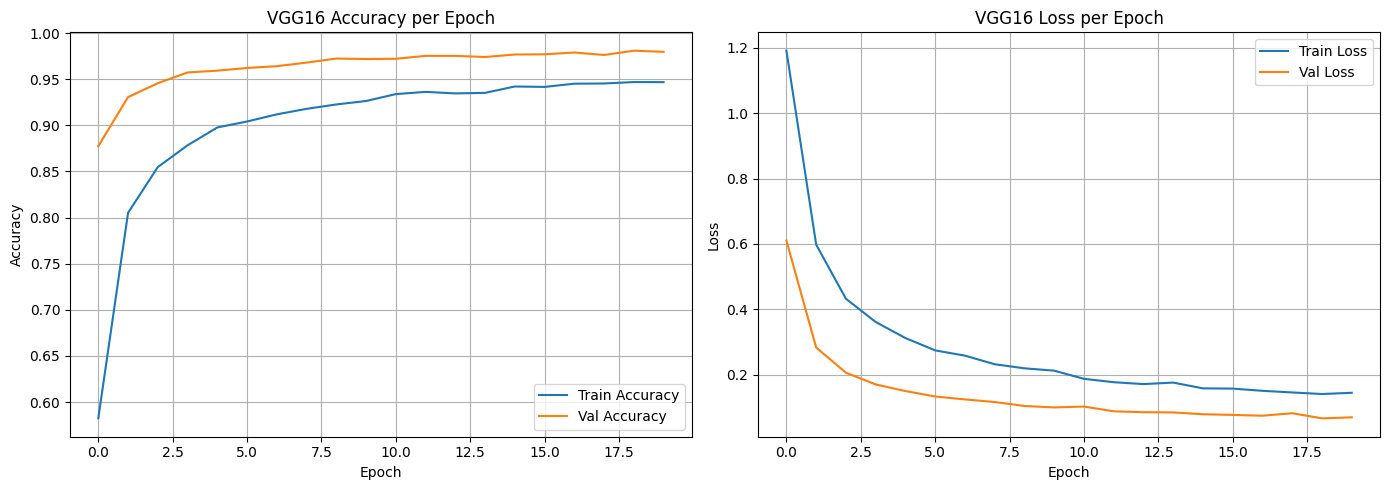

In [18]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(vgg_history.history['accuracy'], label='Train Accuracy')
plt.plot(vgg_history.history['val_accuracy'], label='Val Accuracy')
plt.title('VGG16 Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(vgg_history.history['loss'], label='Train Loss')
plt.plot(vgg_history.history['val_loss'], label='Val Loss')
plt.title('VGG16 Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.grid()
plt.show()

215/215 ━━━━━━━━━━━━━━━━━━━━ 16s 72ms/step


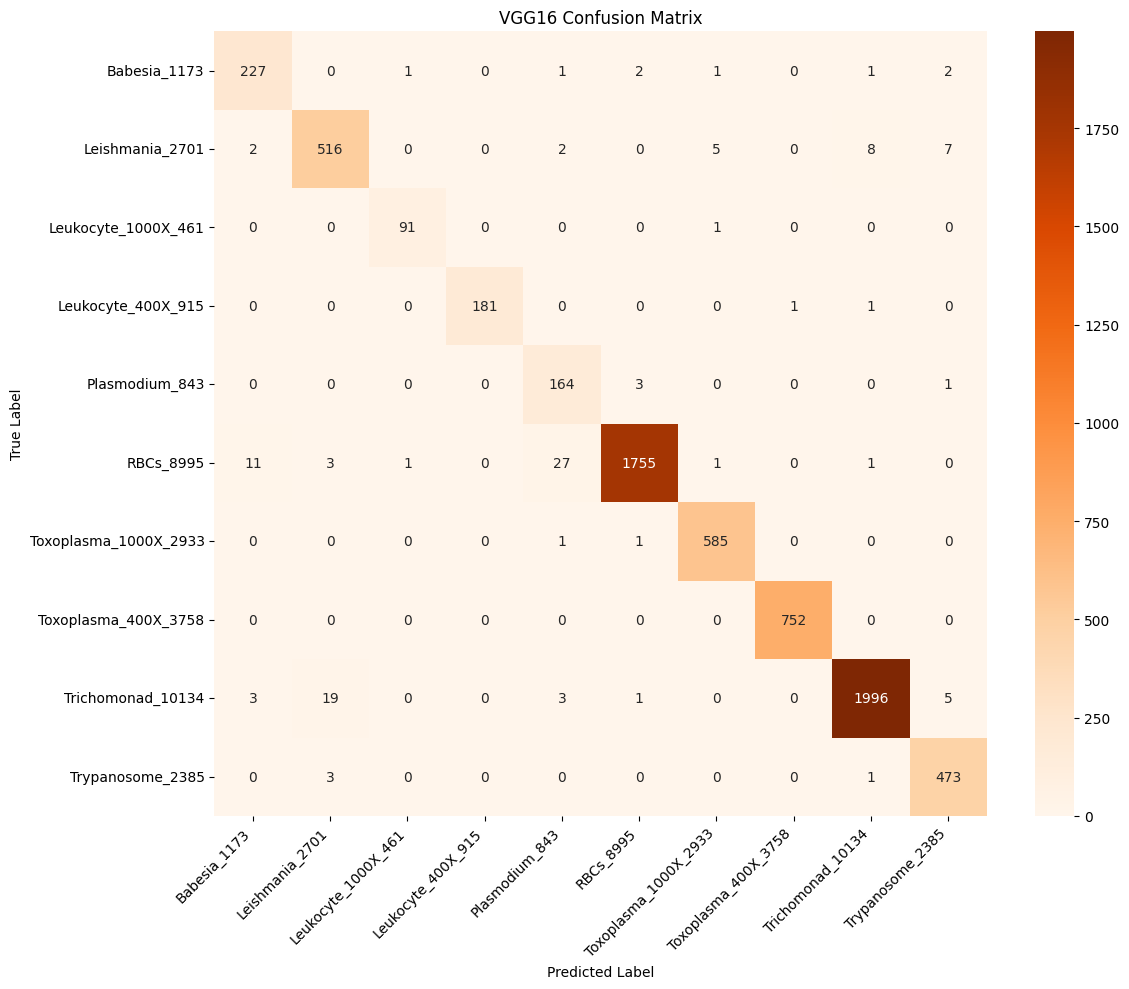

VGG16 Classification Report
                       precision    recall  f1-score   support

         Babesia_1173       0.93      0.97      0.95       235
      Leishmania_2701       0.95      0.96      0.95       540
  Leukocyte_1000X_461       0.98      0.99      0.98        92
   Leukocyte_400X_915       1.00      0.99      0.99       183
       Plasmodium_843       0.83      0.98      0.90       168
            RBCs_8995       1.00      0.98      0.99      1799
Toxoplasma_1000X_2933       0.99      1.00      0.99       587
 Toxoplasma_400X_3758       1.00      1.00      1.00       752
    Trichomonad_10134       0.99      0.98      0.99      2027
     Trypanosome_2385       0.97      0.99      0.98       477

             accuracy                           0.98      6860
            macro avg       0.96      0.98      0.97      6860
         weighted avg       0.98      0.98      0.98      6860



In [19]:
vgg_y_pred_probs=vgg_model.predict(test_dataset)
vgg_y_pred=np.argmax(vgg_y_pred_probs, axis=1)
vgg_y_true=np.concatenate([y for x, y in test_dataset], axis=0)

vgg_cm=confusion_matrix(vgg_y_true, vgg_y_pred)
plt.figure(figsize=(12,10))
sns.heatmap(vgg_cm, annot=True, fmt='d', cmap='Oranges', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('VGG16 Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("VGG16 Classification Report")
print(classification_report(vgg_y_true, vgg_y_pred, target_names=le.classes_))